# Example 03 - QAOA vs classical solvers: an indicative mini-benchmark

Runs the project's benchmark harness on a handful of seeded synthetic six-asset
instances (select three), pairing QAOA against brute force, simulated annealing, a
Markowitz top-k heuristic, and random selection.

This is a **mini-run** sized for a laptop CPU. With so few paired instances the
p-values are indicative only. The curated, full-size numbers (8-28 assets, many
instances, GPU backends) live in [`docs/benchmarks.md`](../docs/benchmarks.md).

This notebook mirrors `03_qaoa_vs_classical.py`, which is the tested source of truth.

In [1]:
from pathlib import Path

from qaoa_portfolio import (
    BenchmarkConfig,
    plot_solver_comparison,
    run_quality_benchmark,
    significance_test,
    summarize_quality,
)

# `mcnemar_test` is not re-exported at package level; import it directly.
from qaoa_portfolio.benchmarks import mcnemar_test

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

REPEATS = 4
NUM_ASSETS = 6
TARGET_ASSETS = 3
SEED = 42

In [2]:
from IPython.display import Image, display

def save_and_show(figures, prefix):
    """Save each figure to output/ (like the script) and display the PNG."""
    paths = []
    for name, figure in figures.items():
        path = OUTPUT_DIR / f"{prefix}_{name}.png"
        figure.savefig(path, bbox_inches="tight", dpi=100)
        paths.append(path)
        display(Image(filename=str(path)))
    return paths

## 1. Configure

Instance `r` uses seed `SEED + r` for its synthetic prices, and every solver sees the
same instance, so results are paired. Leaving `qaoa=None` uses the harness preset:
p = 1, COBYLA, 60 iterations, 2 restarts, on the CPU `default.qubit` simulator.

In [3]:
config = BenchmarkConfig(
    num_assets=NUM_ASSETS,
    target_assets=TARGET_ASSETS,
    repeats=REPEATS,
    seed=SEED,
)

## 2. Run

Every record carries `metadata["feasible"]` (exactly `TARGET_ASSETS` selected); QAOA
records also carry `p_opt` (final probability on the exact optimum) and
`feasible_probability` (probability mass on exactly-k states). Expect roughly
10 seconds per QAOA instance on a CPU.

In [4]:
records = run_quality_benchmark(config)
print(f"{len(records)} records ({REPEATS} instances x 5 solvers)")
for record in records:
    if record.solver_name == "qaoa":
        print(
            f"  instance {record.run_index}: QAOA ratio "
            f"{record.approximation_ratio:.3f}, "
            f"p_opt {record.metadata['p_opt']:.3f}, "
            f"P(feasible) {record.metadata['feasible_probability']:.3f}, "
            f"{record.elapsed_ms / 1000:.1f} s"
        )

20 records (4 instances x 5 solvers)
  instance 0: QAOA ratio 1.000, p_opt 0.037, P(feasible) 0.691, 9.5 s
  instance 1: QAOA ratio 1.000, p_opt 0.031, P(feasible) 0.670, 9.3 s
  instance 2: QAOA ratio 1.000, p_opt 0.029, P(feasible) 0.656, 9.0 s
  instance 3: QAOA ratio 1.000, p_opt 0.038, P(feasible) 0.335, 9.3 s


## 3. Summarize

`summarize_quality` reports, per solver, the mean approximation ratio (1.0 = optimum),
the optimal-hit rate, the feasibility rate, and the mean time; for QAOA also
`mean_p_opt` and `mean_feasible_probability`.

In [5]:
summary = summarize_quality(records)
print(f"{'solver':<20} {'ratio':>7} {'hits':>6} {'feasible':>9} {'ms':>9}")
for name, stats in summary.items():
    print(
        f"{name:<20} {stats['mean_approximation_ratio']:>7.3f} "
        f"{stats['optimal_hit_rate']:>6.0%} "
        f"{stats.get('feasibility_rate', float('nan')):>9.0%} "
        f"{stats['mean_elapsed_ms']:>9.1f}"
    )
qaoa_stats = summary["qaoa"]
print(
    f"QAOA mean p_opt {qaoa_stats['mean_p_opt']:.3f} "
    f"(uniform guess {1 / 2 ** NUM_ASSETS:.3f}), mean P(feasible) "
    f"{qaoa_stats['mean_feasible_probability']:.3f}"
)

solver                 ratio   hits  feasible        ms
brute_force            1.000   100%      100%       0.0
markowitz              0.678    50%      100%       0.2
qaoa                   1.000   100%      100%    9276.8
random                 0.557     0%      100%       0.3
simulated_annealing    1.000   100%      100%       1.2
QAOA mean p_opt 0.034 (uniform guess 0.016), mean P(feasible) 0.588


**Caveat that matters at this size.** QAOA decodes the lowest-objective bitstring
among its `max_stored_solutions` (default 64) most probable states. With 6 assets all
2^6 = 64 states are kept, so the decoded answer is always the optimum and the QAOA
ratio / hit rate are 1.0 by construction. `p_opt` is the honest measure of circuit
quality here; the decoded ratio only becomes informative above 6 assets.

## 4. Statistical tests

The Wilcoxon signed-rank test compares approximation ratios pair by pair; the exact
McNemar test compares who hit the optimum. Both pair records on identical instances.

In [6]:
tests = {}
for baseline in ("random", "markowitz", "simulated_annealing"):
    wilcoxon = significance_test(records, "qaoa", baseline)
    mcnemar = mcnemar_test(records, "qaoa", baseline)
    tests[baseline] = {"wilcoxon": wilcoxon, "mcnemar": mcnemar}
    print(
        f"QAOA vs {baseline:<20} Wilcoxon p = {wilcoxon['p_value']:.3f}   "
        f"McNemar p = {mcnemar['p_value']:.3f} "
        f"(hits {mcnemar['hits_a']}/{mcnemar['num_pairs']} vs "
        f"{mcnemar['hits_b']}/{mcnemar['num_pairs']})"
    )
print(f"Only {REPEATS} pairs: p-values are indicative only.")

QAOA vs random               Wilcoxon p = 0.125   McNemar p = 0.125 (hits 4/4 vs 0/4)
QAOA vs markowitz            Wilcoxon p = 0.500   McNemar p = 0.500 (hits 4/4 vs 2/4)
QAOA vs simulated_annealing  Wilcoxon p = 1.000   McNemar p = 1.000 (hits 4/4 vs 4/4)
Only 4 pairs: p-values are indicative only.


## 5. Figures

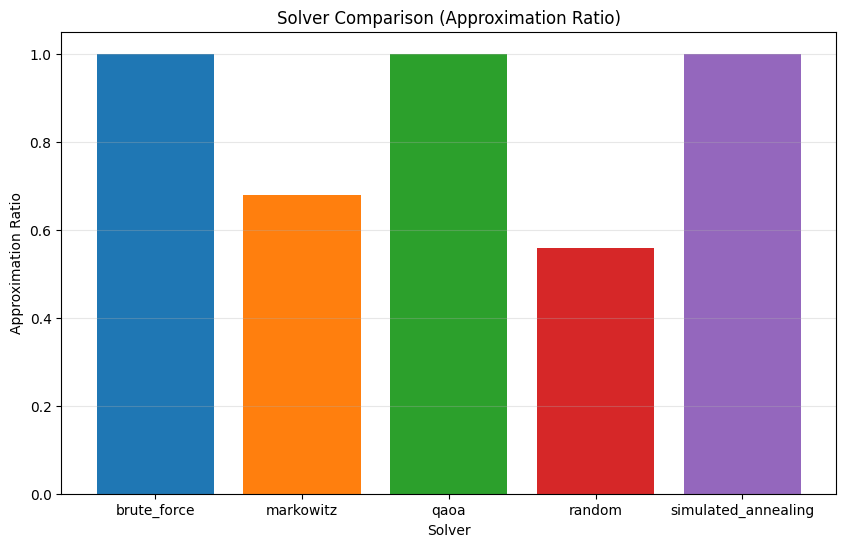

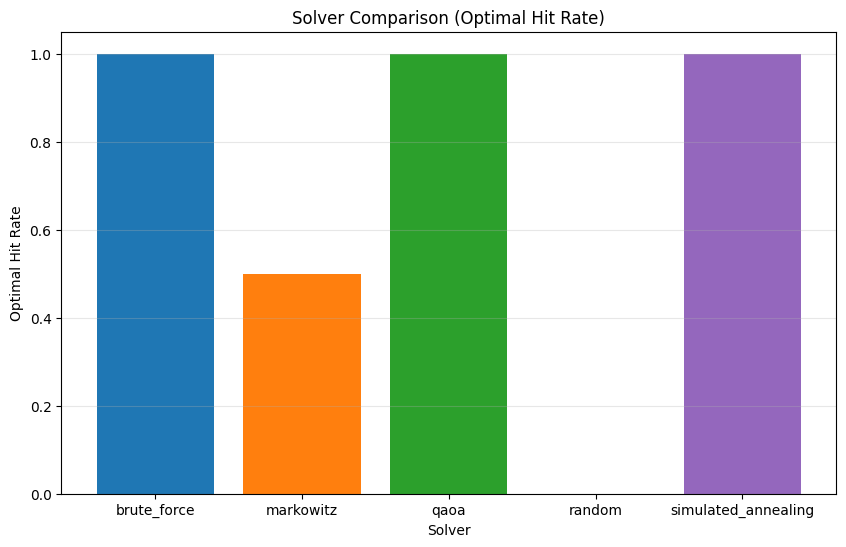

In [7]:
paths = save_and_show(
    {
        "quality": plot_solver_comparison(
            [
                {
                    "solver_name": name,
                    "approximation_ratio": stats["mean_approximation_ratio"],
                }
                for name, stats in summary.items()
            ],
            metric="approximation_ratio",
        ),
        "hit_rate": plot_solver_comparison(
            [
                {"solver_name": name, "optimal_hit_rate": stats["optimal_hit_rate"]}
                for name, stats in summary.items()
            ],
            metric="optimal_hit_rate",
        ),
    },
    prefix="03",
)